## Imports


In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Connection with Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
# Configuring output
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [49]:
info_dict = {
    "ID": "Номер записи",
    "shop_id": "Порядковый номер магазина",
    "item_id": "Порядковый номер товара",
    "item_category_id": "Порядковый номер категории",
    "item_cnt_day": "Продано за день",
    "item_price": "Цена товрара",
    "date": "Дата продажи dd/mm/yyyy",
    "date_block_num": "Порядковый номер месяца, используемый для удобства",
    "item_name": "Название товара",
    "shop_name": "Название магазина",
    "item_category_name": "Название категории товара",
}

In [50]:
def descr_features(df):
    # Exclude ids
    cols = df.columns.drop(["shop_id", "item_id"])
    data = df[cols].copy()

    # Data types
    features = data.dtypes.to_frame(name="data_type")

    # Text description from info_dict
    features["meaning"] = [info_dict.get(x, "new") for x in features.index]

    # Number and percent of missing data
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Number of unique values
    features["nunique"] = data.nunique().values

    # describe() info
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

## Data loading

In [51]:
# Loading train
train = pd.read_csv("/content/drive/MyDrive/ds-practice/data/raw/sales_train.csv")
train.head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0
5,10.01.2013,0,25,2564,349.00,1.0
6,02.01.2013,0,25,2565,549.00,1.0
7,04.01.2013,0,25,2572,239.00,1.0
8,11.01.2013,0,25,2572,299.00,1.0
9,03.01.2013,0,25,2573,299.00,3.0


In [52]:
# Date parsing
train['date'] = pd.to_datetime(train['date'], errors='coerce', format='%d.%m.%Y')

train["day"] = train["date"].apply(lambda x: x.day)
train["month"] = train["date"].apply(lambda x: x.month)
train["year"] = train["date"].apply(lambda x: x.year)

In [53]:
# Loading test
test =  pd.read_csv("/content/drive/MyDrive/ds-practice/data/raw/test.csv")
test.head(10)

,shop_id,item_id
0,5,5037
1,5,5320
2,5,5233
3,5,5232
4,5,5268
5,5,5039
6,5,5041
7,5,5046
8,5,5319
9,5,5003


In [54]:
# Loading items
items = pd.read_csv("/content/drive/MyDrive/ds-practice/data/raw/items.csv")
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [55]:
# Loading shops
shops = pd.read_csv("/content/drive/MyDrive/ds-practice/data/raw/shops.csv")
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [56]:
# Loading categories
categories = pd.read_csv("/content/drive/MyDrive/ds-practice/data/raw/item_categories.csv")
categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [57]:
# Merging train with shops and items
full_train = train.merge(shops, how="left", on="shop_id")
full_train = full_train.merge(items, how="left", on="item_id")
full_train = full_train.merge(categories, how="left", on="item_category_id")

## Data quality control

In [58]:
full_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,day,month,year,shop_name,item_name,item_category_id,item_category_name
0,2013-01-02,0,59,22154,999.00,1.0,2,1,2013,"Ярославль ТЦ ""Альтаир""",ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray
1,2013-01-03,0,25,2552,899.00,1.0,3,1,2013,"Москва ТРК ""Атриум""",DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
2,2013-01-05,0,25,2552,899.00,-1.0,5,1,2013,"Москва ТРК ""Атриум""",DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
3,2013-01-06,0,25,2554,1709.05,1.0,6,1,2013,"Москва ТРК ""Атриум""",DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил
4,2013-01-15,0,25,2555,1099.00,1.0,15,1,2013,"Москва ТРК ""Атриум""",DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства


In [59]:
# Descriptive statistics
descr_features(full_train)

,data_type,meaning,n_NaN,%NaN,nunique,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,datetime64[ns],Дата продажи dd/mm/yyyy,0,0.0,1034,2935849,NaN,NaN,NaN,2014-04-03 05:44:34.970681344,2013-01-01 00:00:00,2013-08-01 00:00:00,2014-03-04 00:00:00,2014-12-05 00:00:00,2015-10-31 00:00:00,NaN
date_block_num,int64,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935849.0,NaN,NaN,NaN,14.6,0.0,7.0,14.0,23.0,33.0,9.4
item_price,float64,Цена товрара,0,0.0,19993,2935849.0,NaN,NaN,NaN,890.9,-1.0,249.0,399.0,999.0,307980.0,1729.8
item_cnt_day,float64,Продано за день,0,0.0,198,2935849.0,NaN,NaN,NaN,1.2,-22.0,1.0,1.0,1.0,2169.0,2.6
day,int64,new,0,0.0,31,2935849.0,NaN,NaN,NaN,15.9,1.0,8.0,16.0,24.0,31.0,8.9
month,int64,new,0,0.0,12,2935849.0,NaN,NaN,NaN,6.2,1.0,3.0,6.0,9.0,12.0,3.5
year,int64,new,0,0.0,3,2935849.0,NaN,NaN,NaN,2013.8,2013.0,2013.0,2014.0,2014.0,2015.0,0.8
shop_name,object,Название магазина,0,0.0,60,2935849,60,"Москва ТЦ ""Семеновский""",235636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_name,object,Название товара,0,0.0,21807,2935849,21807,Фирменный пакет майка 1С Интерес белый (34*42)...,31340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_category_id,int64,Порядковый номер категории,0,0.0,84,2935849.0,NaN,NaN,NaN,40.0,0.0,28.0,40.0,55.0,83.0,17.1


### Completeness

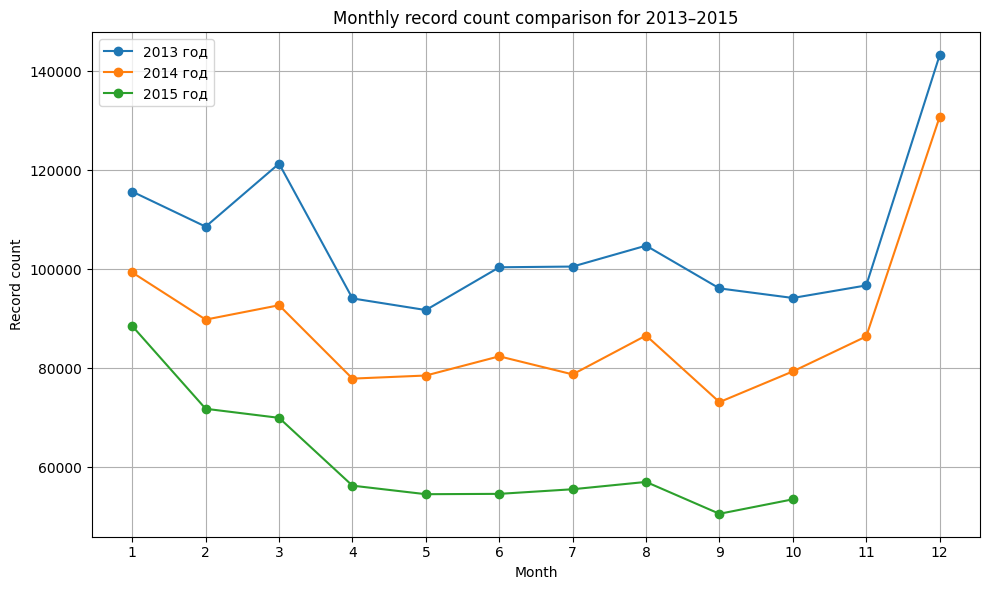

In [60]:
# Define years to visualize monthly record counts
years = [2013, 2014, 2015]

# Dict for monthly records
monthly_data = {}

for year in years:
    data_year = full_train[full_train["year"] == year]
    month_counts = data_year["month"].value_counts().sort_index()
    monthly_data[year] = month_counts

# Initialize plot
plt.figure(figsize=(10, 6))

# Plot monthly record counts for each year
for year in years:
    plt.plot(
        monthly_data[year].index,
        monthly_data[year].values,
        marker='o',
        label=f'{year} год'
    )

# Add plot title and axis labels
plt.title('Monthly record count comparison for 2013–2015')
plt.xlabel('Month')
plt.ylabel('Record count')
plt.xticks(range(1, 13))  # Months from 1 to 12
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot demonstrates high data completeness for each month from 2013 to 2015. There are a significant number of records, ranging from 60,000 to 140,000. This indicates a stable and consistent presentation of information over time and enables reliable comparative analysis of seasonal fluctuations.

In [61]:
# Shops missing from the train
unused_shops = shops[~shops['shop_id'].isin(train['shop_id'])]
num_unused_shops = len(unused_shops)

# Items missing from the train
unused_items = items[~items['item_id'].isin(train['item_id'])]
num_unused_items = len(unused_items)

print(f"Missing shops in the training set: {num_unused_shops}")
print(f"Missing items in the training set: {num_unused_items}")

Missing shops in the training set: 0
Missing items in the training set: 363


All shops listed in the reference table are present in the sales data, yet 363 items have never been sold. Since the forecast is planned for the full assortment, these items should remain in the training set with zero sales assigned.

**Conclusion:** there are no missing values, but 363 items have never been sold. Therefore, the criterion of data completeness is not fully met.

### Uniqueness

In [62]:
sorted(shops["shop_name"].unique())

['!Якутск Орджоникидзе, 56 фран',
 '!Якутск ТЦ "Центральный" фран',
 'Адыгея ТЦ "Мега"',
 'Балашиха ТРК "Октябрь-Киномир"',
 'Волжский ТЦ "Волга Молл"',
 'Вологда ТРЦ "Мармелад"',
 'Воронеж (Плехановская, 13)',
 'Воронеж ТРЦ "Максимир"',
 'Воронеж ТРЦ Сити-Парк "Град"',
 'Выездная Торговля',
 'Жуковский ул. Чкалова 39м?',
 'Жуковский ул. Чкалова 39м²',
 'Интернет-магазин ЧС',
 'Казань ТЦ "Бехетле"',
 'Казань ТЦ "ПаркХаус" II',
 'Калуга ТРЦ "XXI век"',
 'Коломна ТЦ "Рио"',
 'Красноярск ТЦ "Взлетка Плаза"',
 'Красноярск ТЦ "Июнь"',
 'Курск ТЦ "Пушкинский"',
 'Москва "Распродажа"',
 'Москва МТРЦ "Афи Молл"',
 'Москва Магазин С21',
 'Москва ТК "Буденовский" (пав.А2)',
 'Москва ТК "Буденовский" (пав.К7)',
 'Москва ТРК "Атриум"',
 'Москва ТЦ "Ареал" (Беляево)',
 'Москва ТЦ "МЕГА Белая Дача II"',
 'Москва ТЦ "МЕГА Теплый Стан" II',
 'Москва ТЦ "Новый век" (Новокосино)',
 'Москва ТЦ "Перловский"',
 'Москва ТЦ "Семеновский"',
 'Москва ТЦ "Серебряный Дом"',
 'Мытищи ТРК "XL-3"',
 'Н.Новгород ТРЦ

Some shop names appear twice with extra characters in their titles: Якутск Орджоникидзе, 56; Якутск ТЦ "Центральный; Жуковский ул. Чкалова 39м².

In [63]:
sorted(categories["item_category_name"].unique())

['PC - Гарнитуры/Наушники',
 'Аксессуары - PS2',
 'Аксессуары - PS3',
 'Аксессуары - PS4',
 'Аксессуары - PSP',
 'Аксессуары - PSVita',
 'Аксессуары - XBOX 360',
 'Аксессуары - XBOX ONE',
 'Билеты (Цифра)',
 'Доставка товара',
 'Игровые консоли - PS2',
 'Игровые консоли - PS3',
 'Игровые консоли - PS4',
 'Игровые консоли - PSP',
 'Игровые консоли - PSVita',
 'Игровые консоли - XBOX 360',
 'Игровые консоли - XBOX ONE',
 'Игровые консоли - Прочие',
 'Игры - PS2',
 'Игры - PS3',
 'Игры - PS4',
 'Игры - PSP',
 'Игры - PSVita',
 'Игры - XBOX 360',
 'Игры - XBOX ONE',
 'Игры - Аксессуары для игр',
 'Игры Android - Цифра',
 'Игры MAC - Цифра',
 'Игры PC - Дополнительные издания',
 'Игры PC - Коллекционные издания',
 'Игры PC - Стандартные издания',
 'Игры PC - Цифра',
 'Карты оплаты (Кино, Музыка, Игры)',
 'Карты оплаты - Live!',
 'Карты оплаты - Live! (Цифра)',
 'Карты оплаты - PSN',
 'Карты оплаты - Windows (Цифра)',
 'Кино - Blu-Ray',
 'Кино - Blu-Ray 3D',
 'Кино - Blu-Ray 4K',
 'Кино - DV

In [64]:
print(f"Number of duplicates in items by id: {items['item_id'].duplicated().sum()}")
print(f"Number of duplicates in items: {items.duplicated().sum()}")
print(f"Percent of duplicates in items: {items.duplicated().sum()/full_train.shape[0]}\n")

Number of duplicates in items by id: 0
Number of duplicates in items: 0
Percent of duplicates in items: 0.0



In [65]:
print(f"Number of duplicates in shops by id: {shops['shop_id'].duplicated().sum()}")
print(f"Number of duplicates in shops: {shops.duplicated().sum()}")
print(f"Percent of duplicates in shops: {shops.duplicated().sum()/full_train.shape[0]}\n")

Number of duplicates in shops by id: 0
Number of duplicates in shops: 0
Percent of duplicates in shops: 0.0



In [66]:
print(f"Number of duplicates in categories by id: {categories['item_category_id'].duplicated().sum()}")
print(f"Number of duplicates in categories: {categories.duplicated().sum()}")
print(f"Percent of duplicates in categories: {categories.duplicated().sum()/full_train.shape[0]}\n")

Number of duplicates in categories by id: 0
Number of duplicates in categories: 0
Percent of duplicates in categories: 0.0



In [67]:
# Identify full duplicates
dups = full_train[full_train.duplicated()]
print(f"Number of full duplicates: {dups.shape[0]}")
print(f"Percent of full duplicates: {dups.shape[0]/full_train.shape[0]}\n")

Number of full duplicates: 6
Percent of full duplicates: 2.0437018388888528e-06



In [68]:
dups

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,day,month,year,shop_name,item_name,item_category_id,item_category_name
76962,2013-01-05,0,54,20130,149.0,1.0,5,1,2013,"Химки ТЦ ""Мега""",УЧЕНИК ЧАРОДЕЯ (регион),40,Кино - DVD
1435367,2014-02-23,13,50,3423,999.0,1.0,23,2,2014,"Тюмень ТЦ ""Гудвин""","Far Cry 3 (Classics) [Xbox 360, русская версия]",23,Игры - XBOX 360
1496766,2014-03-23,14,21,3423,999.0,1.0,23,3,2014,"Москва МТРЦ ""Афи Молл""","Far Cry 3 (Classics) [Xbox 360, русская версия]",23,Игры - XBOX 360
1671873,2014-05-01,16,50,3423,999.0,1.0,1,5,2014,"Тюмень ТЦ ""Гудвин""","Far Cry 3 (Classics) [Xbox 360, русская версия]",23,Игры - XBOX 360
1866340,2014-07-12,18,25,3423,999.0,1.0,12,7,2014,"Москва ТРК ""Атриум""","Far Cry 3 (Classics) [Xbox 360, русская версия]",23,Игры - XBOX 360
2198566,2014-12-31,23,42,21619,499.0,1.0,31,12,2014,"СПб ТК ""Невский Центр""",ЧЕЛОВЕК ДОЖДЯ (BD),37,Кино - Blu-Ray


Duplicates in data differ. They are not associated with a particular shop or item and occured on different dates. There are 6 fully identical rows in dataset.



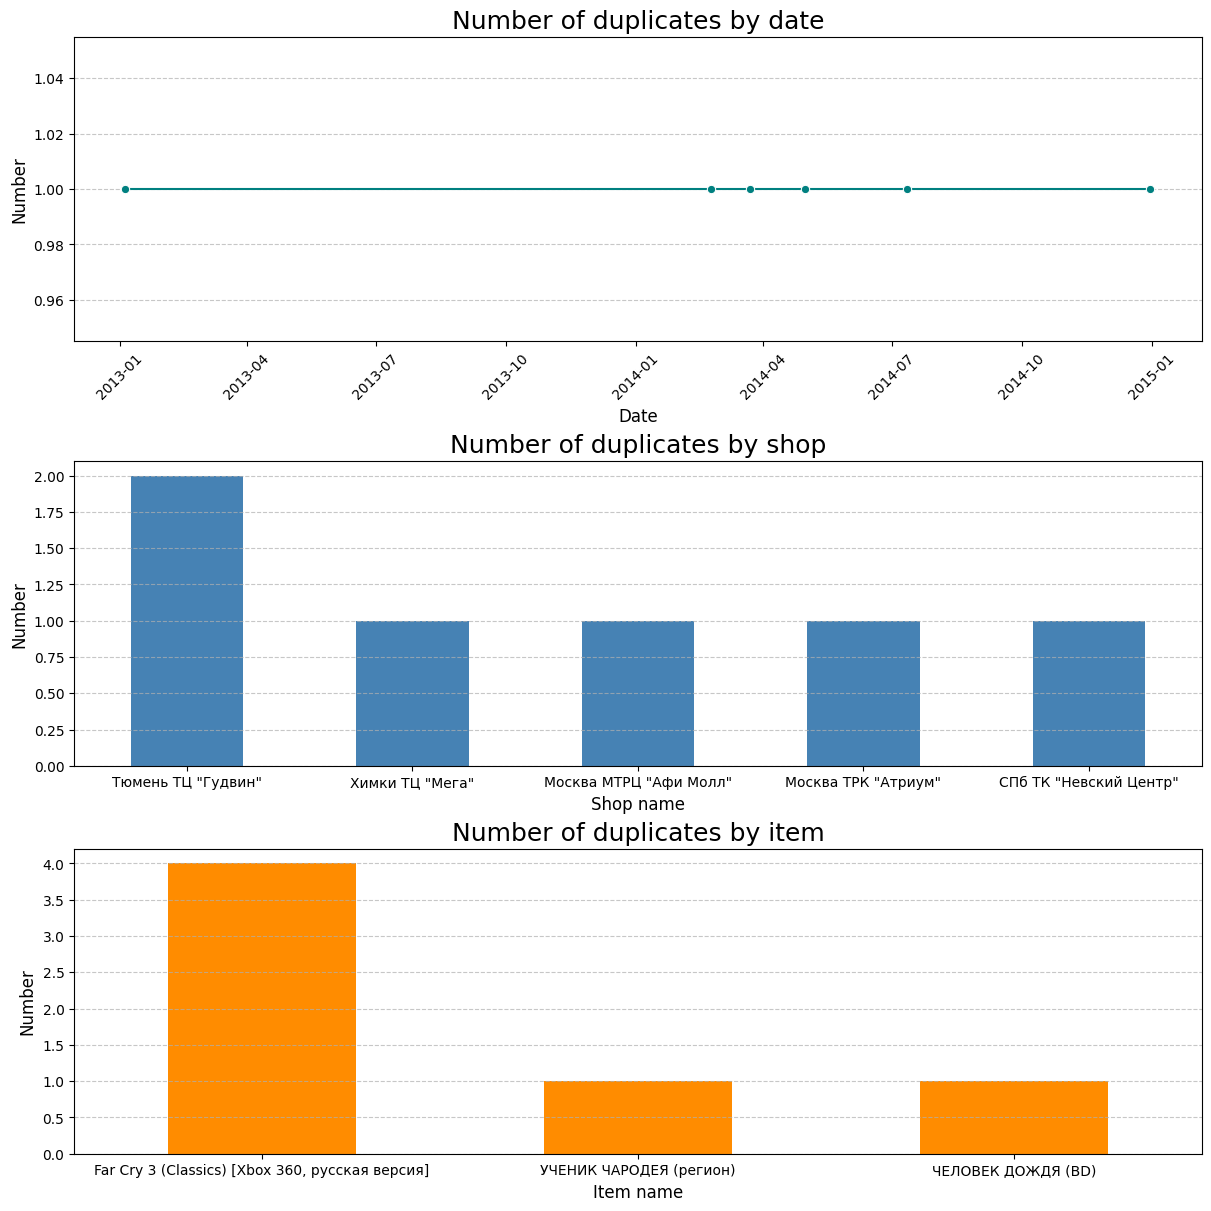

In [69]:
# Counting values
date_counts = dups['date'].value_counts().sort_index()
store_counts = dups['shop_name'].value_counts()
item_counts = dups['item_name'].value_counts()

fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

# Duplicates by date
sns.lineplot(ax=axes[0], x=date_counts.index, y=date_counts.values, marker='o', color='teal')
axes[0].set_title('Number of duplicates by date', fontsize=18)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Number', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Duplicates by shop
store_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Number of duplicates by shop', fontsize=18)
axes[1].set_xlabel('Shop name', fontsize=12)
axes[1].set_ylabel('Number', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Duplicates by item
item_counts.plot(kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('Number of duplicates by item', fontsize=18)
axes[2].set_xlabel('Item name', fontsize=12)
axes[2].set_ylabel('Number', fontsize=12)
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

As shown in the chart, the item Far Cry 3 has more duplicates than the others. This may indicate either its popularity or accounting mistakes.

Duplicates may occur due to repeated sales of the same item on the same day at the same price and quantity. It is not necessarily an error, but may reflect stable demond, a limited assortment or the absence of a unique transaction id.

Since the data will be aggregated by month, such duplicates can be retained, as they reflect repeated sales and can be aggregated correctly.

**Conclusion:** the data is unique, there are less than 1% of full duplicates (repeated sales)

### Consistency

In [70]:
# Aggregate unique date_block_num values for each year-month pair
aggregated = full_train.groupby(['year', 'month'])['date_block_num'].unique().reset_index()
aggregated

,year,month,date_block_num
0,2013,1,[0]
1,2013,2,[1]
2,2013,3,[2]
3,2013,4,[3]
4,2013,5,[4]
5,2013,6,[5]
6,2013,7,[6]
7,2013,8,[7]
8,2013,9,[8]
9,2013,10,[9]


In [71]:
# Shops
missing_shops = set(full_train['shop_id']) - set(shops['shop_id'])
print(f'Shops without description: {missing_shops}')

# Categories
missing_categories = set(full_train['item_category_id']) - set(categories['item_category_id'])
print(f'Categories without description: {missing_categories}')

# Items
missing_items = set(full_train['item_id']) - set(items['item_id'])
print(f'Items without description: {missing_items}')

Shops without description: set()
Categories without description: set()
Items without description: set()


In [72]:
# Merge items info
merged = train.merge(items, on='item_id', how='left')

missing_after_merge = merged['item_name'].isnull().sum()
print(f'Number of rows without item name after merge: {missing_after_merge}')

missing_after_merge = merged['item_category_id'].isnull().sum()
print(f'Number of rows without item categories after merge: {missing_after_merge}')

# Merge cats info
merged = merged.merge(categories, on='item_category_id', how='left')

missing_after_merge = merged['item_category_name'].isnull().sum()
print(f'Number of rows without category name after merge: {missing_after_merge}')

Number of rows without item name after merge: 0
Number of rows without item categories after merge: 0
Number of rows without category name after merge: 0


In [73]:
# Merge shops info
merged = train.merge(shops, on='shop_id', how='left')

missing_after_merge = merged['shop_name'].isnull().sum()
print(f'Number of rows without shop name after merge: {missing_after_merge}')

Number of rows without shop name after merge: 0


In [74]:
# Consistency check for shop_id и item_id in the test set

# Check that each shop_id is in reference table
valid_shops = test['shop_id'].isin(shops['shop_id'])
print(f"Nuber of inconsistent shop_ids: {test[~valid_shops].shape[0]}")

# Check that each item_id is in reference table
valid_items = test['item_id'].isin(items['item_id'])
print(f"Number of inconsistent item_ids: {test[~valid_items].shape[0]}")

Nuber of inconsistent shop_ids: 0
Number of inconsistent item_ids: 0


**Вывод:** the data satisfies the consistency condition:
- each date_block_num matches a unique combination of month and year;
- each shop, category and item has description from the corresponding table;
- left joins don't result in any information loss.

### Timeliness

In [75]:
print("Years in the train set:", full_train.year.unique())
print("Months of the 2015th year in the train set:", full_train.loc[full_train["year"]==2015, "month"].unique())

Years in the train set: [2013 2014 2015]
Months of the 2015th year in the train set: [ 1  2  3  4  5  6  7  8  9 10]


**Conclusion:** we have sufficient data to make a forcast for November 2015.

### Accuracy

According to the statistics dataframe, prices range from -1 to 307980 (in arbitrary units).

In [76]:
full_train["item_price"].min()

-1.0

In [77]:
full_train["item_price"].max()

307980.0

In [78]:
full_train[full_train["item_price"]==-1]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,day,month,year,shop_name,item_name,item_category_id,item_category_name
484683,2013-05-15,4,32,2973,-1.0,1.0,15,5,2013,"Москва ТЦ ""Серебряный Дом""","DmC Devil May Cry [PS3, русские субтитры]",19,Игры - PS3


Possible reasons for the appearance of a negative price:

Data loading or transformation error — incorrect file parsing, rounding issues, or type conversion mistakes.

Incorrect handling of returns — the return was recorded via a negative price instead of a negative quantity. In our dataset, returns are represented by negative quantities (ranging from -22 to 2169).

Test or garbage record — the row may have been added for testing purposes and accidentally remained in the final dataset.

Since this is a single row, it is reasonable to remove it.

**Conclusion:** item_price has negative values. Appart from that, the data is accurate

### Validity

In [79]:
# Data types
full_train.dtypes

,0
date,datetime64[ns]
date_block_num,int64
shop_id,int64
item_id,int64
item_price,float64
item_cnt_day,float64
day,int64
month,int64
year,int64
shop_name,object


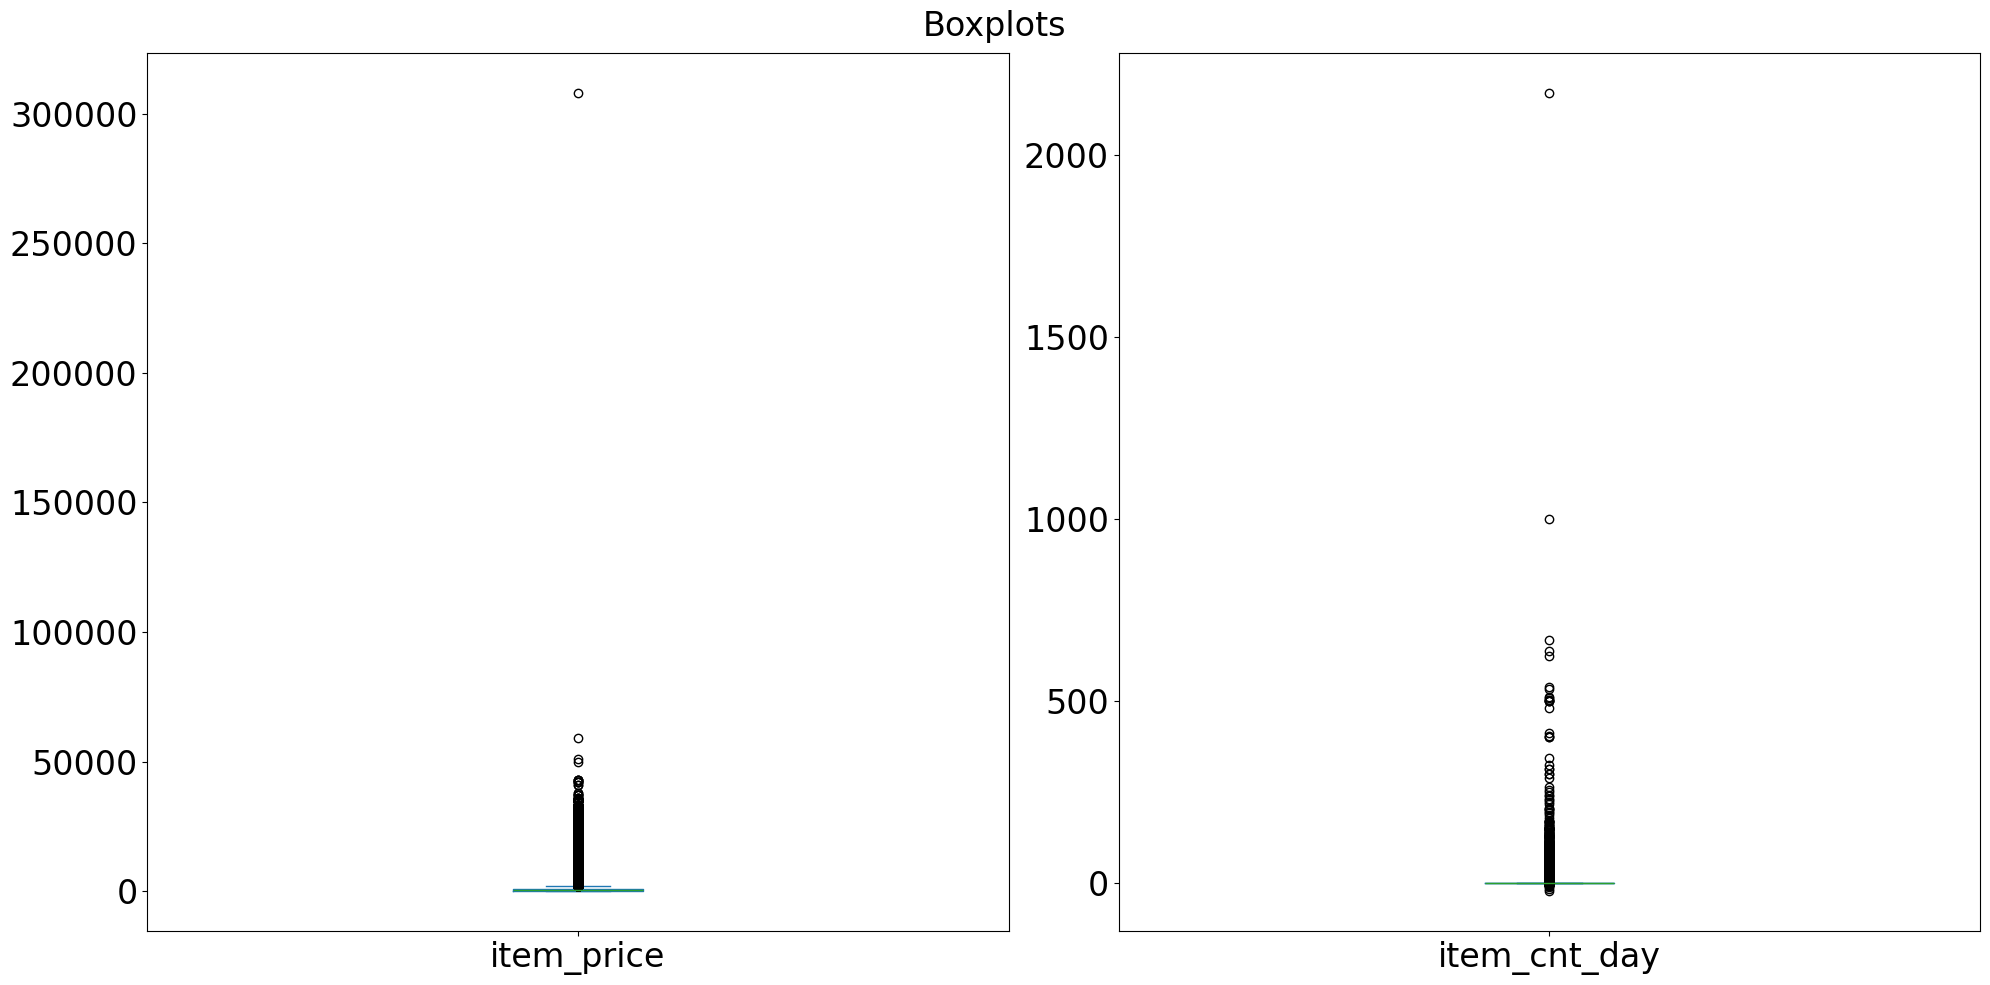

In [80]:
# Plotting a boxplot
ax = full_train[["item_price", "item_cnt_day", ]].plot(kind="box", subplots=True, figsize=(20, 10), fontsize=24)
plt.suptitle("Boxplots", fontsize=24, x=0.5)
plt.tight_layout()

In [81]:
def get_bounds(data, column):
    q25 = data[column].quantile(0.25) # calculation of interquartile range
    q75 = data[column].quantile(0.75)
    iqr = q75 - q25
    bound = (q25 - iqr * 1.5, q75 + iqr * 1.5)
    out_of_bound = ( data[column] > bound[1]) | ( data[column] < bound[0])
    anom_count = data[column][ out_of_bound ].count()

    print("\033[1m",column,"\033[0m")
    print("Interquartile range", bound)
    print(f"Data range: ({data[column].min()}; {data[column].max()})")
    print("Number of outliers: ", anom_count)
    print("Percent of outliers: ", anom_count / len(data) * 100, '\n')

    return [bound[0], bound[1], out_of_bound]

In [82]:
for col in train.columns:
  get_bounds(train, col)

 date 
Interquartile range (Timestamp('2011-07-26 12:00:00'), Timestamp('2016-12-10 12:00:00'))
Data range: (2013-01-01 00:00:00; 2015-10-31 00:00:00)
Number of outliers:  0
Percent of outliers:  0.0 

 date_block_num 
Interquartile range (np.float64(-17.0), np.float64(47.0))
Data range: (0; 33)
Number of outliers:  0
Percent of outliers:  0.0 

 shop_id 
Interquartile range (np.float64(-15.5), np.float64(84.5))
Data range: (0; 59)
Number of outliers:  0
Percent of outliers:  0.0 

 item_id 
Interquartile range (np.float64(-12336.0), np.float64(32496.0))
Data range: (0; 22169)
Number of outliers:  0
Percent of outliers:  0.0 

 item_price 
Interquartile range (np.float64(-876.0), np.float64(2124.0))
Data range: (-1.0; 307980.0)
Number of outliers:  258942
Percent of outliers:  8.820004026092624 

 item_cnt_day 
Interquartile range (np.float64(1.0), np.float64(1.0))
Data range: (-22.0; 2169.0)
Number of outliers:  306477
Percent of outliers:  10.439126807952317 

 day 
Interquartile ran

**Conclusion:** The item count feature is of integer type. It is reasonable to convert float to int. There are outliers in both the count and price features, they are not errorsbut rather plausible high values. Data is valid.

### Clarity

In [83]:
# Check keys
print("item_id is unique:", items['item_id'].is_unique)
print("shop_id is unique:", shops['shop_id'].is_unique)

item_id is unique: True
shop_id is unique: True


In [84]:
# Verify one-to-one mappings

print("Each item_id corresponds to a single category:",
      items.groupby('item_id')['item_category_id'].nunique().max() == 1)

print("Each item_id corresponds to a single name:",
      items.groupby('item_id')['item_name'].nunique().max() == 1)

print("Each shop_id corresponds to a single name:",
      shops.groupby('shop_id')['shop_name'].nunique().max() == 1)

Each item_id corresponds to a single category: True
Each item_id corresponds to a single name: True
Each shop_id corresponds to a single name: True


In [85]:
# Сheck feature atonomy

def check_atomic(column):
    return column.apply(lambda x: not isinstance(x, (list, tuple, dict)))

atomic_items = items.apply(check_atomic).all().all()
atomic_shops = shops.apply(check_atomic).all().all()
atomic_sales = full_train.apply(check_atomic).all().all()


print("All values in items are atomic:", atomic_items)
print("All values in shops are atomic:", atomic_shops)
print("All values in sales are atomic:", atomic_sales)

All values in items are atomic: True
All values in shops are atomic: True
All values in sales are atomic: True


**Conclusion:** clarity is satisfied. Each item_id corresponds to a single category. Each item_id corresponds to a single name. Each shop_id corresponds to a single name. All values are atomic.

### Result

**DQC conclusion:** the data is of good quality, and the size of the DataFrame is suitable for model training. It is necessary to remove non-informative features, convert data types, and handle anomalies and incorrect values. Additionally, before training the model, the training set should be completed with missing combinations of items and shops.

## ETL

In [86]:
# Drop row with negative price
train.drop(train[train["item_price"]==-1].index, inplace=True)

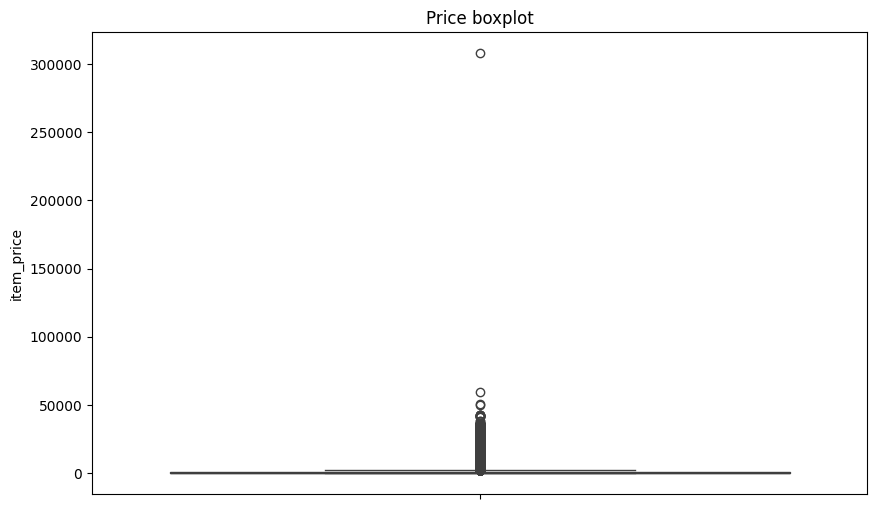

In [87]:
plt.figure(figsize=(10, 6))
sns.boxplot(train['item_price'])
plt.title('Price boxplot')
plt.show()

In [88]:
# Drop anomaly in price
train.drop(train[train["item_price"]>200000].index, inplace=True)

In [89]:
# Convert types to int32
int_columns = train.columns.drop(["item_price", "date"])
train[int_columns] = train[int_columns].astype("int32")
print(train[int_columns].dtypes)

date_block_num    int32
shop_id           int32
item_id           int32
item_cnt_day      int32
day               int32
month             int32
year              int32
dtype: object


In [90]:
# Dict of shop_ids
shop_id_map = {
    0: 57,   # Якутск Орджоникидзе, 56
    1: 58,   # Якутск ТЦ "Центральный"
    10: 11   # Жуковский ул. Чкалова 39м²
}

# Replace shop_ids in train and test
train['shop_id'] = train['shop_id'].replace(shop_id_map)
test['shop_id'] = test['shop_id'].replace(shop_id_map)

In [91]:
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,min,25%,50%,75%,max,std
date,datetime64[ns],Дата продажи dd/mm/yyyy,0,0.0,1034,2935847,2014-04-03 05:44:47.757094144,2013-01-01 00:00:00,2013-08-01 00:00:00,2014-03-04 00:00:00,2014-12-05 00:00:00,2015-10-31 00:00:00,NaN
date_block_num,int32,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935847.0,14.6,0.0,7.0,14.0,23.0,33.0,9.4
item_price,float64,Цена товрара,0,0.0,19991,2935847.0,890.7,0.1,249.0,399.0,999.0,59200.0,1720.5
item_cnt_day,int32,Продано за день,0,0.0,198,2935847.0,1.2,-22.0,1.0,1.0,1.0,2169.0,2.6
day,int32,new,0,0.0,31,2935847.0,15.9,1.0,8.0,16.0,24.0,31.0,8.9
month,int32,new,0,0.0,12,2935847.0,6.2,1.0,3.0,6.0,9.0,12.0,3.5
year,int32,new,0,0.0,3,2935847.0,2013.8,2013.0,2013.0,2014.0,2014.0,2015.0,0.8


### Saving to a file

In [92]:
train.to_csv("/content/drive/MyDrive/ds-practice/data/processed/train_after_ETL.csv", index=False)